### Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset

#### Descriptive Analytics for Numerical Columns

-	Objective: To compute and analyze basic statistical measures for numerical columns in the dataset.
-	Steps:
	Load the dataset into a data analysis tool or programming environment (e.g., Python with pandas library).
	Identify numerical columns in the dataset.
	Calculate the mean, median, mode, and standard deviation for these columns.
	Provide a brief interpretation of these statistics.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('sales_data_with_discounts.csv')
df.head(5)

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


In [4]:
print(df['City'].value_counts())
print(df['BU'].value_counts())
print(df['Brand'].value_counts())
print(df['Model'].value_counts())

City
C    450
Name: count, dtype: int64
BU
Mobiles      150
FMCG         150
Lifestyle    150
Name: count, dtype: int64
Brand
Jeera      90
Gear       60
Viva       60
RealU      45
YouM       45
Babaji     45
Vedic      45
Sumsang    30
Orange     30
Name: count, dtype: int64
Model
RU-10             15
RU-9 Plus         15
M-Formals         15
W-Lounge          15
W-Western         15
M-Casuals         15
M-Jeans           15
W-Inners          15
W-Casuals         15
M- Inners         15
M- T Shirts       15
Gear BB Cream     15
Gear Shampoo      15
Gear Cream        15
Gear Oil          15
Vedic Oil         15
Babaji Cream      15
Babaji Shampoo    15
Vedic Shampoo     15
Vedic Cream       15
Babaji Oil        15
O-11              15
O-10              15
S-21              15
S-20              15
RU-9              15
YM-98             15
YM-99 Plus        15
YM-99             15
M-Shoes           15
Name: count, dtype: int64


In [5]:
df_numeric = df.select_dtypes(include=['number'])
df_numeric.head()

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,15,12100,181500,11.654820,21153.498820,160346.501180
1,10,10100,101000,11.560498,11676.102961,89323.897039
2,7,16100,112700,9.456886,10657.910157,102042.089843
3,6,20100,120600,6.935385,8364.074702,112235.925298
4,3,8100,24300,17.995663,4372.946230,19927.053770


In [6]:
stats = pd.DataFrame({
    "Mean" : df_numeric.mean(),
    "Median" : df_numeric.median(),
    "Mode" : df_numeric.mode().iloc[0],
    "Standard_deviation": df_numeric.std()
})
print(stats)

                           Mean       Median          Mode  Standard_deviation
Volume                 5.066667     4.000000      3.000000            4.231602
Avg Price          10453.433333  1450.000000    400.000000        18079.904840
Total Sales Value  33812.835556  5700.000000  24300.000000        50535.074173
Discount Rate (%)     15.155242    16.577766      5.007822            4.220602
Discount Amount     3346.499424   988.933733     69.177942         4509.902963
Net Sales Value    30466.336131  4677.788059    326.974801        46358.656624


###### Volume 
- Most sales involve around 4 units, but a few larger orders increase the average to 5 units. The standard deviation of 4 shows that the number of units sold varies moderately between transactions.
###### Avg Price
- Most products are priced around 1,450, but a small number of expensive products push the average price up to 10,453. The high standard deviation (18,079) shows that product prices differ a lot.
###### Total Sales Value
- Most sales are worth around 5,700, but a few very large transactions raise the average to 33,812. The high standard deviation (50,535) suggests that sales values vary greatly from one transaction to another.
###### Discount Rate (%)
- The mean and median are very close, which means discount percentages are fairly consistent across most transactions. The standard deviation of 4 indicates only moderate variation in discount rates.
###### Discount Amount
- Most customers receive discounts of less than 1,000, but customers making expensive purchases get much larger discounts, increasing the average discount to 3,346. The high standard deviation shows that discount amounts vary considerably.
###### Net Sales Value
- Most customers spend around 4,677 after discounts. However, a few high-value purchases increase the average significantly. The high standard deviation (46,358) indicates a wide spread in net sales values.  

#### Data Visualization

-	Objective: To visualize the distribution and relationship of numerical and categorical variables in the dataset.
-	Histograms:
	Plot histograms for each numerical column.	Analyze the distribution (e.g., skewness, presence of outliers) and provide inferences.
-	Box Plots:
	Create boxplots for numerical variables to identify outliers and the interquartile range.
	Discuss any findings, such as extreme values or unusual distributions.
-	Bar Chart Analysis for Categorical Column:
	Identify categorical columns in the dataset.
	Create bar charts to visualize the frequency or count of each category.
	Analyze the distribution of categories and provide insights.

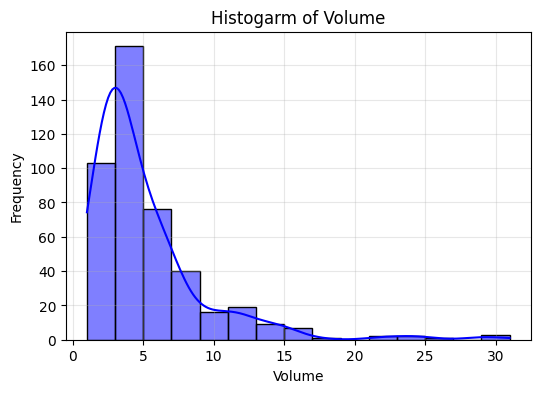

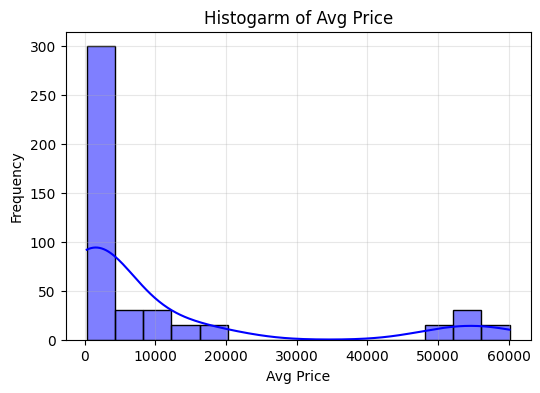

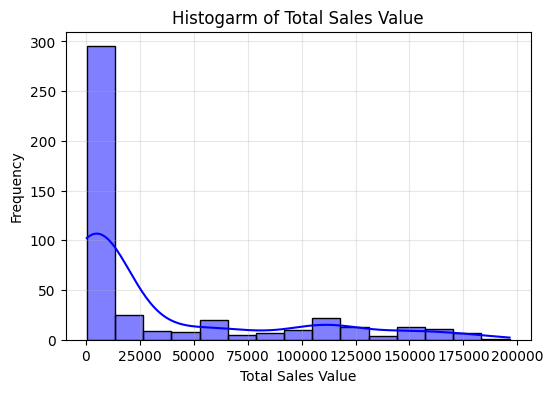

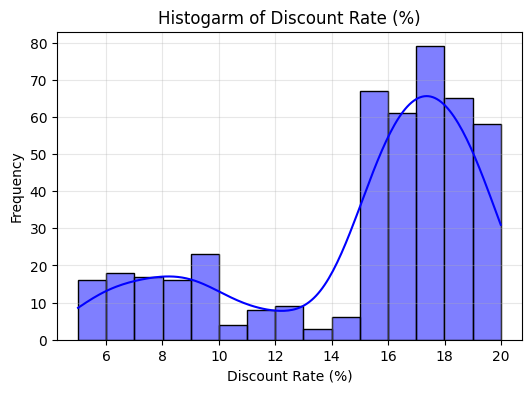

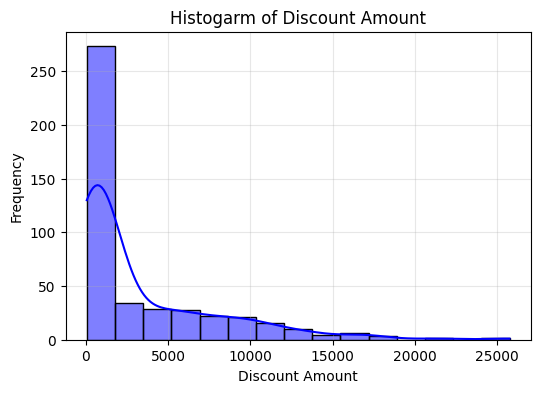

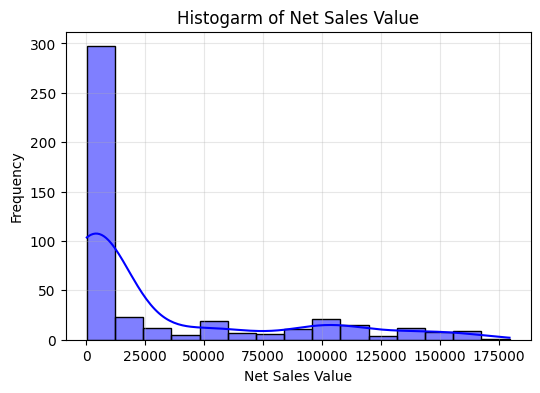

In [7]:
for column in df_numeric:
    plt.figure(figsize=(6,4))
    sns.histplot(df[column], bins=15, color = 'blue', edgecolor='black',kde=True)
    plt.title(f"Histogarm of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

##### Histogram of Volume
- Most volume values are concentrated between 2 - 6, with the highest frequency around 3 - 4, the distribution is positively right skewed indicating the most observation having lower volume values while few have higher volume.
##### Histogram of Avg Price
- Most avg prices are conentrated between 0 to 5,000, with higer frequency in lower price range, the distribution is positively right skewed, indicating that most items have lower average prices, whie only few have very high prices. A small cluster of observation between 50,000 - 60,000
##### Histogram of Total Sales Value
- Most total sales are between 0 - 12500, with the highest frequency in the lower sales value range, the disstribution is positively right skewed indicating that most transaction have lower sales value, while only a few transaction have very high sales values. 
##### Histogram of Discount Rate(%)
- Most of the discount rate in this histogram are between 15 - 20% with the highest frequency in 18% the distribution appears to be bimodal suggesting 2 groups of discount rate, the distribution is left skewed. A small cluster exists around 5-10%, while few observation fall under 11 and 15%.
##### Histogram of Discount Amount
- most of the discount amount are concentrated between 0 - 2000, with the highest frequency in the lower discount amount range. the distribution is positively right skewed, indicating that most transaction have smaller discount rates while onlhy a few transaction having very high discount amount.
##### Histogram of Net Sales Value
- Most net sales values are concentrated between 0 and 12,500, with the highest frequency in the lower net sales value range,the distribution is positively right skewed, indicating that most transactions have lower net sales values, while only a few transactions have very high net sales values.

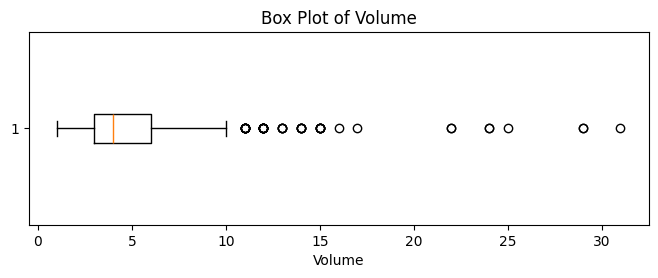

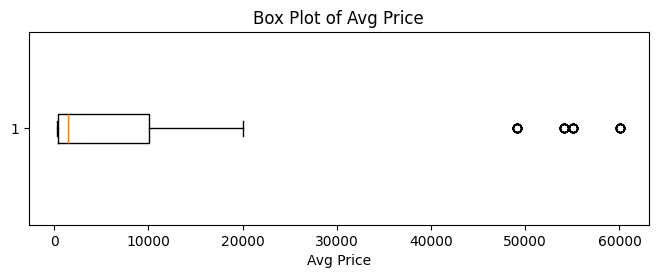

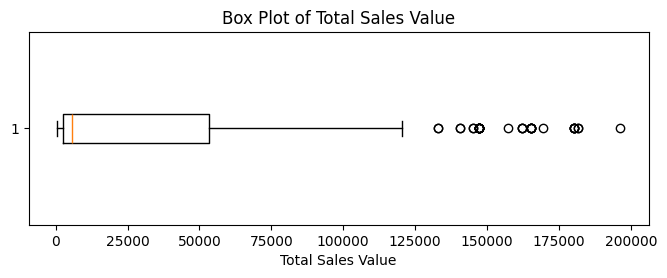

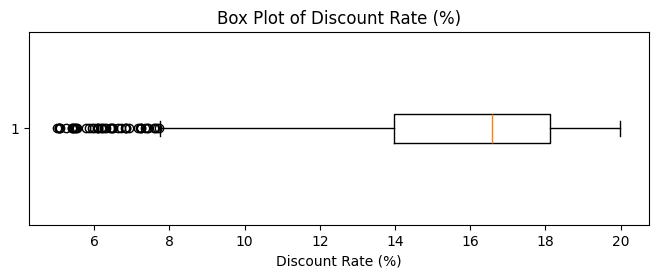

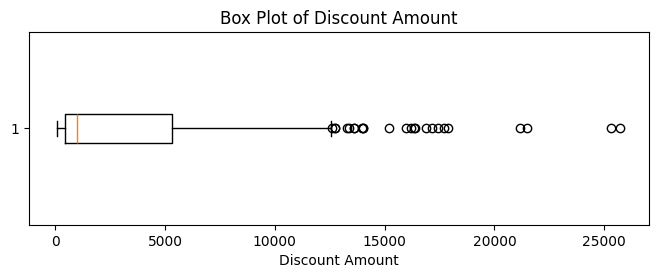

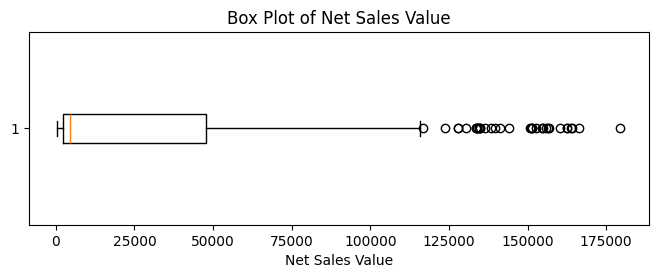

In [8]:
for column in df_numeric:
    plt.figure(figsize=(8,2.5))
    plt.boxplot(df[column], vert=False)
    plt.title(f'Box Plot of {column}')
    plt.xlabel(column)
    plt.show()

##### Box plot of volume
- The orange line is the median and its around 4, whle the middle 50% od observation lie between 3 and 6, the whiskers extend from about 1 to 10 indicating the range of non outlier value. Several observation above 10 indicates outliers, no lower outliers are observed, Q1-3, Q3-6 (approx).
##### Box plot of Avg Price 
- The median avg price lies near the lower end while the middle 50% of the observation are concentrated approx between 500 - 10,000, the whiskers extend from about 0 to 20000 indicating no range of outlier values, observation between 49,000 - 60,000 are identified as upper outliers.
##### Box Plot of Total Sales Value
- The median avg price lies near the lower end while the middle 50% of the observation are concentrated approx between 2,000 - 55,000, the whiskers extend from about 0 to 120000, several observation between 130,000 - 200,000 are identified as upper outliers
##### Box Plot of Discount Rate(%)
- The median discount rate is approx 16.5, while middle 50% of observation lie between 14 - 18%, the whiskers extend from about 8 - 20%. Several observations between 5% and 8% are identified as lower outliers.
##### Box Plot of Discount Amount
- The median discount amount is approx 1,000, while the middle 50% of the observations lie between 300 and 5,500, The whiskers extend from about 0 to 12,500. Several observations between 13,000 and 26,000 are identified as upper outliers.
##### Box Plot of Net Sales Value
- The median net sales value is approximately 4,000, while the middle 50% of the observations lie between 2,000 and 48,000, The whiskers extend from about 0 to 115,000, representing the range of non outlier values. Several observations between 120,000 and 180,000 are identified as upper outliers.

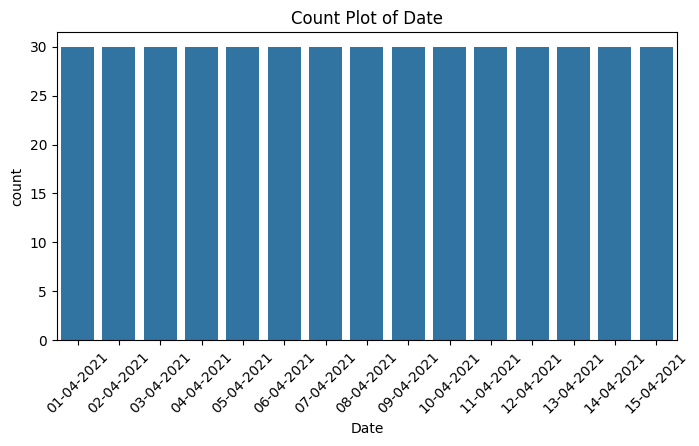

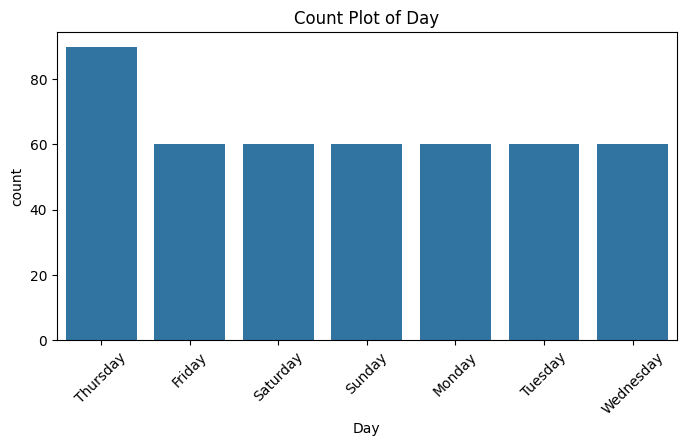

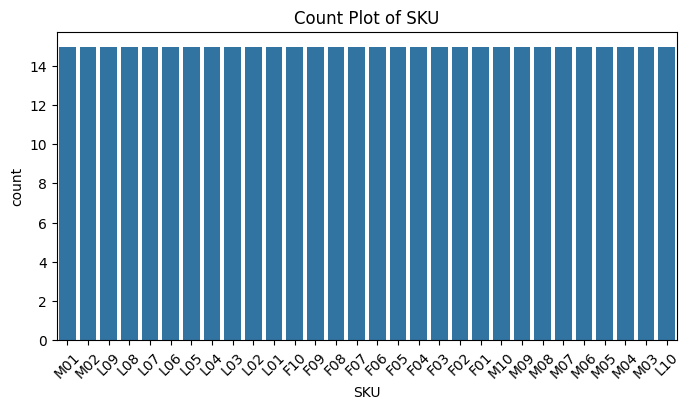

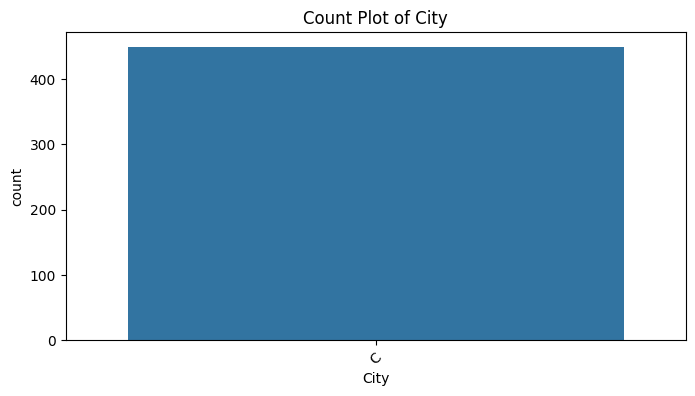

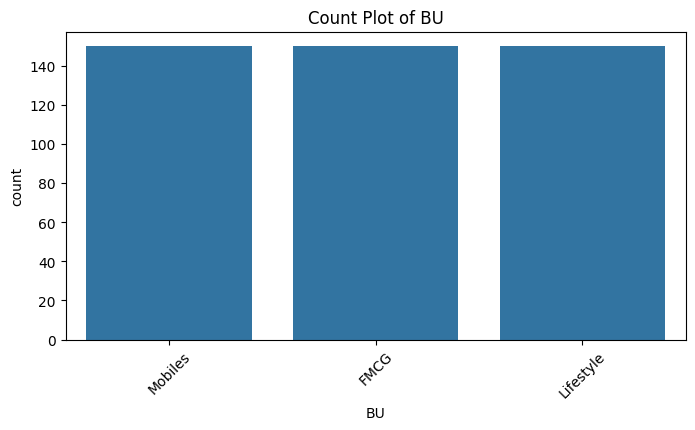

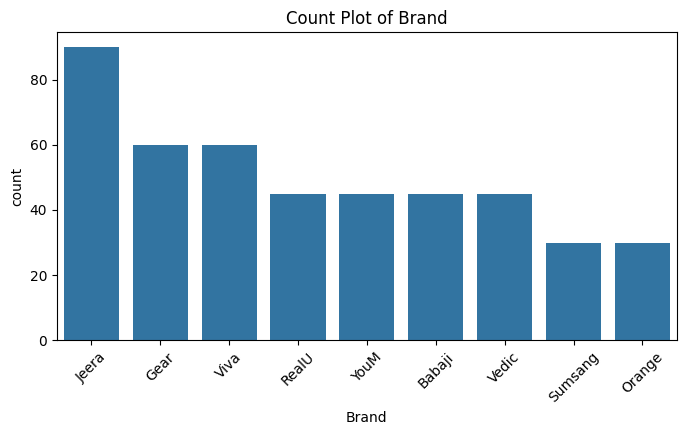

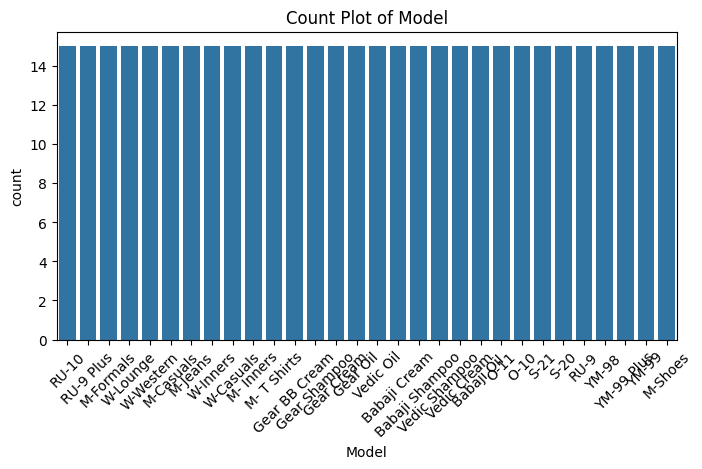

In [9]:
categorical_columns = df.select_dtypes(include='object').columns
for column in categorical_columns:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df,x=column,order=df[column].value_counts().index)
    plt.title(f'Count Plot of {column}')
    plt.xticks(rotation=45)
    plt.show()

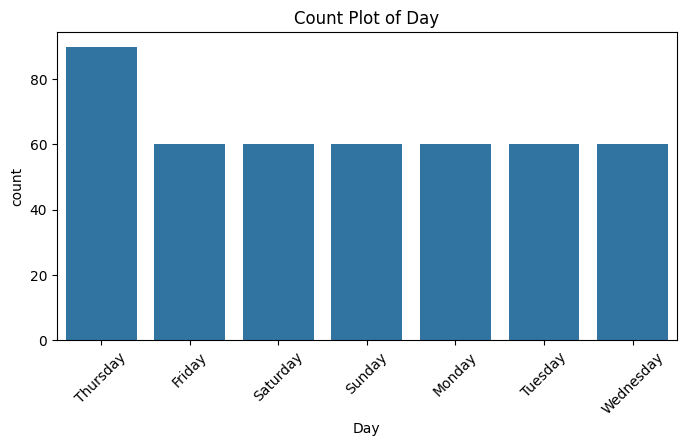

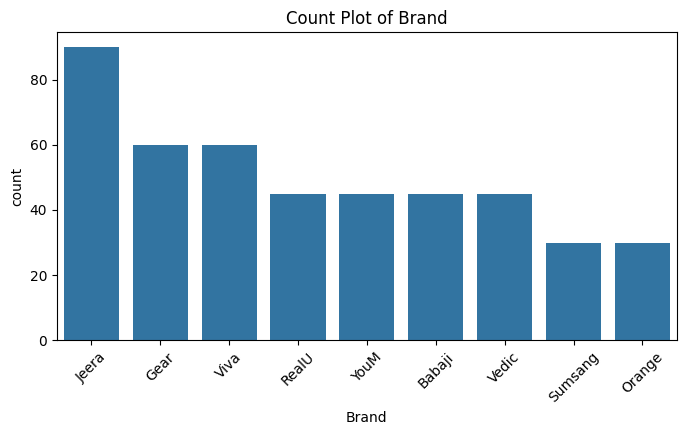

In [10]:
categorical_columns1 = ['Day', 'Brand']
for column in categorical_columns1:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df,x=column,order=df[column].value_counts().index)
    plt.title(f'Count Plot of {column}')
    plt.xticks(rotation=45)
    plt.show()

##### Bar Chart for Day
- Thrusday has the highest number of observation, while each of remaining days has 60 observation. The data is fairly balanced across the daysof the week, except for thursday.
##### Bar Chart for Brand
- Jeera has the highest number of observations (90), followed by Gear and Viva (60 each). RealU, YouM, Babaji, and Vedic each have 45 observations, while Sumsang and Orange have the lowest number of observations (30 each). This indicates that the dataset is not evenly distributed across brands, with Jeera being the most represented brand.

##### Overall Conclusion
- Most numerical variables (Average Price, Total Sales Value, Discount Amount, and Net Sales Value) are positively (right) skewed because a small number of high-value transactions increase the averages.
- Volume shows moderate variation with only a few unusually large orders.
- Discount Rate (%) is the most consistent numerical variable, with relatively little variation and few outliers.
- Among the categorical variables, Brand, SKU, BU, and Model show different frequencies across categories, while City contains only one category and therefore offers no comparative insight.